# Differentially Private Gaussian Naive Bayes Classifier - Breast Cancer Wisconsin Dataset

This notebook implements a Differentially Private Gaussian Naive Bayes classifier using `diffprivlib` on the Wisconsin Breast Cancer dataset and compares its performance with the standard (non-private) model.

## Implementation:
- Uses `diffprivlib.models.GaussianNB` with epsilon-differential privacy
- Applies privacy guarantees to mean and variance estimation
- Feature bounds are required for proper privacy calibration

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix, 
    f1_score,
    precision_score,
    recall_score,
)
from diffprivlib.models import GaussianNB as DPGaussianNB
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
import pickle
# Load the scaled data
with open("../data/processed_data.pkl", "rb") as f: 
    loaded_data = pickle.load(f)

X_train, X_test = loaded_data["X_train"], loaded_data["X_test"]
y_train, y_test = loaded_data["y_train"], loaded_data["y_test"]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (455, 30)
Test set: (114, 30)


## 3. Load Baseline Results

In [3]:
# Load baseline results from standard model
try:
    baseline_df = pd.read_csv('output/baseline_results.csv')
    baseline_accuracy = baseline_df['accuracy'].values[0]
    baseline_f1 = baseline_df['f1_score'].values[0]
    print("Baseline results loaded successfully!")
    print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
    print(f"Baseline F1-Score: {baseline_f1:.4f}")
except FileNotFoundError:
    print("Warning: baseline_results.csv not found. Please run STD_GNB.ipynb first.")
    baseline_accuracy = None
    baseline_f1 = None

Baseline results loaded successfully!
Baseline Accuracy: 0.9211
Baseline F1-Score: 0.8889


## 4. Define Feature Bounds for Differential Privacy

**CRITICAL FIX**: The data is **StandardScaled** (mean≈0, std=1), so bounds must match the scaled data!

### Tunable Hyperparameters for DP-GaussianNB:
1. **epsilon** (float): Privacy budget - lower = more privacy but worse utility
2. **bounds** (tuple): Feature ranges - MUST match scaled data distribution
3. **var_smoothing** (float, default=1e-9): Stability parameter for variance calculation
4. **priors** (array, default=None): Prior class probabilities

**Recommendation**: Use bounds=(-3, 3) for StandardScaled data (covers 99.7% of values)

In [4]:
import numpy as np

# FIXED: Using bounds for StandardScaled data (mean=0, std=1)
# Option 1: Uniform bounds (recommended for StandardScaled data)
lower_bound = -3.0  # Covers ~99.7% of data (-3 standard deviations)
upper_bound = 3.0   # Covers ~99.7% of data (+3 standard deviations)

print(f"Using uniform bounds for scaled data: [{lower_bound}, {upper_bound}]")
print("This assumes MinMaxScaler normalization to [-1, 1]")
print("Covers approximately 99.7% of the standardized distribution")

# Verify actual data range
print(f"\nActual data range:")
print(f"  X_train min: {X_train.min():.4f}")
print(f"  X_train max: {X_train.max():.4f}")

# Alternative: Use tighter bounds if you accept clipping outliers
# lower_bound = -2.5
# upper_bound = 2.5

Using uniform bounds for scaled data: [-3.0, 3.0]
This assumes MinMaxScaler normalization to [-1, 1]
Covers approximately 99.7% of the standardized distribution

Actual data range:
  X_train min: -1.0000
  X_train max: 1.0000


## 5. Train Differentially Private Gaussian Naive Bayes Model

In [5]:
# Define epsilon value for differential privacy
epsilon = 1.0
N_RUNS = 30

# Store per-run metrics for the detailed evaluation at epsilon=1.0
detail_accuracies = []
detail_f1s = []
detail_precisions = []
detail_recalls = []
detail_cms = []  # confusion matrices
 
print(f"Training DP Gaussian Naive Bayes {N_RUNS} times with epsilon={epsilon}...")
print("=" * 60)

detail_extra = ExtraMetrics()
for run in range(N_RUNS): 
    seed = run * 10 + 42  # fixed sequence for reproducibility
    
    # Initialize and train DP Gaussian Naive Bayes with CORRECTED BOUNDS
    dp_gnb = DPGaussianNB(
        epsilon=epsilon,
        bounds=(lower_bound, upper_bound),  # NOW USING SCALED DATA BOUNDS
        var_smoothing=1e-9  # Default value, can tune if needed
    )

    _t0 = time.perf_counter()
    dp_gnb.fit(X_train, y_train)
    train_time = time.perf_counter() - _t0

    y_dp_pred = dp_gnb.predict(X_test)
    
    # Calculate metrics
    dp_accuracy = accuracy_score(y_test, y_dp_pred)
    detail_extra.add(y_test, y_dp_pred, model=dp_gnb, X=X_test, train_time=train_time)
    dp_f1 = f1_score(y_test, y_dp_pred)
    dp_precision = precision_score(y_test, y_dp_pred, zero_division=0)
    dp_recall = recall_score(y_test, y_dp_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_dp_pred)

    detail_accuracies.append(dp_accuracy)
    detail_f1s.append(dp_f1)
    detail_precisions.append(dp_precision)
    detail_recalls.append(dp_recall)
    detail_cms.append(cm)

    print(f"  Run {run+1:2d}/{N_RUNS} | Acc: {dp_accuracy:.4f} | F1: {dp_f1:.4f} | Prec: {dp_precision:.4f} | Rec: {dp_recall:.4f}")

print("Added metrics over the detail runs:")
print(detail_extra.describe())

Training DP Gaussian Naive Bayes 30 times with epsilon=1.0...
  Run  1/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run  2/30 | Acc: 0.3684 | F1: 0.5385 | Prec: 0.3684 | Rec: 1.0000
  Run  3/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run  4/30 | Acc: 0.3509 | F1: 0.4559 | Prec: 0.3298 | Rec: 0.7381
  Run  5/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run  6/30 | Acc: 0.7193 | F1: 0.4839 | Prec: 0.7500 | Rec: 0.3571
  Run  7/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run  8/30 | Acc: 0.3684 | F1: 0.5385 | Prec: 0.3684 | Rec: 1.0000
  Run  9/30 | Acc: 0.6228 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 10/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 11/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 12/30 | Acc: 0.5614 | F1: 0.5833 | Prec: 0.4487 | Rec: 0.8333
  Run 13/30 | Acc: 0.7105 | F1: 0.3529 | Prec: 1.0000 | Rec: 0.2143
  Run 14/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 

  Run 24/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000


  Run 25/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000


  Run 26/30 | Acc: 0.3684 | F1: 0.5385 | Prec: 0.3684 | Rec: 1.0000
  Run 27/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 28/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 29/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
  Run 30/30 | Acc: 0.6316 | F1: 0.0000 | Prec: 0.0000 | Rec: 0.0000
Added metrics over the detail runs:
  Balanced Acc:   0.5120 ± 0.0405
  AUROC:          0.7221 ± 0.2119
  Train Time (s): 0.0064 ± 0.0003


## 6. Model Evaluation

In [6]:
avg_accuracy = float(np.mean(detail_accuracies))
avg_f1_score = float(np.mean(detail_f1s))
avg_precision = float(np.mean(detail_precisions))
avg_recall = float(np.mean(detail_recalls))

std_accuracy = float(np.std(detail_accuracies))
std_f1_score = float(np.std(detail_f1s))
std_precision = float(np.std(detail_precisions))
std_recall = float(np.std(detail_recalls))

print("=" * 60)
print(f"\nResults over {N_RUNS} runs at epsilon={epsilon}:")
print(f"  Accuracy:  {avg_accuracy:.4f} ± {std_accuracy:.4f}")
print(f"  F1-Score:  {avg_f1_score:.4f} ± {std_f1_score:.4f}")
print(f"  Precision: {avg_precision:.4f} ± {std_precision:.4f}")
print(f"  Recall:    {avg_recall:.4f} ± {std_recall:.4f}")


Results over 30 runs at epsilon=1.0:
  Accuracy:  0.5904 ± 0.1032
  F1-Score:  0.1487 ± 0.2247
  Precision: 0.1654 ± 0.2621
  Recall:    0.2143 ± 0.3691


## 7. Confusion Matrix

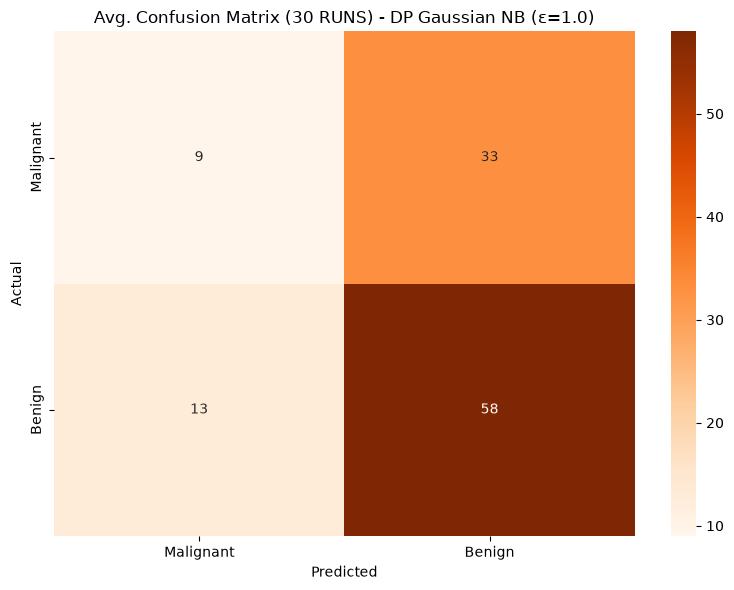


Confusion Matrix:
[[ 9 33]
 [13 58]]


In [7]:
avg_cm = np.mean(detail_cms, axis=0).astype(int)

TN = avg_cm[0, 0]
FP = avg_cm[0, 1]
FN = avg_cm[1, 0]
TP = avg_cm[1, 1]

custom_cm = np.array([
    [TP, FN], 
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f'Avg. Confusion Matrix ({N_RUNS} RUNS) - DP Gaussian NB (ε={epsilon})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)

## 8. Compare with Baseline (Standard Model)

In [8]:
if baseline_accuracy is not None:
    accuracy_loss = baseline_accuracy - avg_accuracy
    f1_loss = baseline_f1 - avg_f1_score
    
    print("=" * 50)
    print("COMPARISON: Standard vs DP Gaussian Naive Bayes")
    print("=" * 50)
    print(f"\nStandard Model Accuracy: {baseline_accuracy:.4f}")
    print(f"DP Model Accuracy (avg): {avg_accuracy:.4f}")
    print(f"Accuracy Loss:           {accuracy_loss:.4f} ({accuracy_loss*100:.2f}%)")
    print(f"\nStandard Model F1-Score: {baseline_f1:.4f}")
    print(f"DP Model F1-Score (avg): {avg_f1_score:.4f}")
    print(f"F1 Loss:                 {f1_loss:.4f} ({f1_loss*100:.2f}%)")
else:
    print("Baseline results not available. Run STD_GNB.ipynb first.")

COMPARISON: Standard vs DP Gaussian Naive Bayes

Standard Model Accuracy: 0.9211
DP Model Accuracy (avg): 0.5904
Accuracy Loss:           0.3307 (33.07%)

Standard Model F1-Score: 0.8889
DP Model F1-Score (avg): 0.1487
F1 Loss:                 0.7402 (74.02%)


## 9. Prepare JSON Report Structure

In [9]:
import json
 
N_RUNS = 30
 
parameters = {
    "model": "DP-GaussianNB",
    "priors": "None (learned from data)",
    "bounds": "Per-feature bounds",
    "n_runs": N_RUNS,
}
 
results_json = {
    "model_type": "Differentially Private Gaussian Naive Bayes",
    "n_runs_per_epsilon": N_RUNS,
    "epsilon_results": {}
}

## 10. Epsilon vs Accuracy Analysis

Testing different privacy budget (epsilon) values to observe the trade-off between privacy and accuracy.

In [10]:
epsilon_values = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 4.0, 6.0, 8.0, 10.0]
 
# Store aggregated results
results = {
    'epsilon': [],
    'accuracy_mean': [],
    'accuracy_std': [],
    'f1_score_mean': [],
    'f1_score_std': [],
    'precision_mean': [],
    'precision_std': [],
    'recall_mean': [],
    'recall_std': [],
}
 
print(f"Training DP Gaussian NB with {N_RUNS} runs per epsilon value...")
print("=" * 80)
 
for eps in epsilon_values:
    run_accuracies = []
    run_f1s = []
    run_precisions = []
    run_recalls = []
    run_cms = []
 
    extra = ExtraMetrics()
    for run in range(N_RUNS):
        seed = run * 10 + 42
 
        dp_gnb = DPGaussianNB(
            epsilon=eps,
            bounds=(lower_bound, upper_bound),  # CORRECTED: using scaled data bounds
            var_smoothing=1e-9
        )
        _t0 = time.perf_counter()
        dp_gnb.fit(X_train, y_train)
        train_time = time.perf_counter() - _t0
        
        # Export model for MIA (only first run per epsilon)
        if run == 0:
            import sys
            import os
            sys.path.append(os.path.abspath(os.path.join('..', '..')))
            from model_exporter import export_model
            export_model(dp_gnb, f'output/model/dp_gnb_model_eps_{eps}.pkl')
        
        y_pred = dp_gnb.predict(X_test)
 
        acc = accuracy_score(y_test, y_pred)
        extra.add(y_test, y_pred, model=dp_gnb, X=X_test, train_time=train_time)
        f1 = f1_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
 
        run_accuracies.append(acc)
        run_f1s.append(f1)
        run_precisions.append(prec)
        run_recalls.append(rec)
        run_cms.append(cm.tolist())
 
    # Compute statistics
    acc_mean, acc_std = np.mean(run_accuracies), np.std(run_accuracies)
    f1_mean, f1_std = np.mean(run_f1s), np.std(run_f1s)
    prec_mean, prec_std = np.mean(run_precisions), np.std(run_precisions)
    rec_mean, rec_std = np.mean(run_recalls), np.std(run_recalls)
 
    results['epsilon'].append(eps)
    # Merge in the added metrics; keys the notebook already tracks are skipped.
    for _key, _value in extra.summary().items():
        results.setdefault(_key, []).append(_value)
    results['accuracy_mean'].append(acc_mean)
    results['accuracy_std'].append(acc_std)
    results['f1_score_mean'].append(f1_mean)
    results['f1_score_std'].append(f1_std)
    results['precision_mean'].append(prec_mean)
    results['precision_std'].append(prec_std)
    results['recall_mean'].append(rec_mean)
    results['recall_std'].append(rec_std)
 
    results_json["epsilon_results"][str(eps)] = {
        "epsilon": float(eps),
        "n_runs": N_RUNS,
        "accuracy_mean": acc_mean,
        "accuracy_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "precision_mean": prec_mean,
        "precision_std": prec_std,
        "recall_mean": rec_mean,
        "recall_std": rec_std,
        "per_run_accuracies": run_accuracies,
        "per_run_f1s": run_f1s,
        "per_run_precisions": run_precisions,
        "per_run_recalls": run_recalls,
        "per_run_confusion_matrices": run_cms,
        "parameters": parameters.copy()
    }
    results_json["epsilon_results"][str(eps)].update(extra.summary())
    results_json["epsilon_results"][str(eps)].update(extra.per_run())
 
    print(f"ε={eps:5.1f} | Acc: {acc_mean:.4f}±{acc_std:.4f} | "
          f"F1: {f1_mean:.4f}±{f1_std:.4f} | "
          f"Prec: {prec_mean:.4f}±{prec_std:.4f} | "
          f"Rec: {rec_mean:.4f}±{rec_std:.4f}")
 
print("=" * 80)
print("Training complete!")

Training DP Gaussian NB with 30 runs per epsilon value...


Model successfully exported to output/model/dp_gnb_model_eps_0.1.pkl


ε=  0.1 | Acc: 0.4874±0.1522 | F1: 0.3345±0.2688 | Prec: 0.2512±0.2211 | Rec: 0.5667±0.4659
Model successfully exported to output/model/dp_gnb_model_eps_0.2.pkl


ε=  0.2 | Acc: 0.5368±0.1234 | F1: 0.2376±0.2555 | Prec: 0.2398±0.2773 | Rec: 0.3937±0.4667
Model successfully exported to output/model/dp_gnb_model_eps_0.4.pkl


ε=  0.4 | Acc: 0.5518±0.1263 | F1: 0.1750±0.2528 | Prec: 0.1613±0.2473 | Rec: 0.2968±0.4401
Model successfully exported to output/model/dp_gnb_model_eps_0.6.pkl


...

ε=  2.0 | Acc: 0.6237±0.0884 | F1: 0.1565±0.2280 | Prec: 0.3205±0.3947 | Rec: 0.1603±0.2850
Model successfully exported to output/model/dp_gnb_model_eps_4.0.pkl


ε=  4.0 | Acc: 0.6591±0.0443 | F1: 0.1422±0.2038 | Prec: 0.5257±0.4703 | Rec: 0.1087±0.2039
Model successfully exported to output/model/dp_gnb_model_eps_6.0.pkl


ε=  6.0 | Acc: 0.6906±0.1021 | F1: 0.3132±0.2823 | Prec: 0.6644±0.3850 | Rec: 0.2635±0.2929
Model successfully exported to output/model/dp_gnb_model_eps_8.0.pkl


ε=  8.0 | Acc: 0.7430±0.0938 | F1: 0.4443±0.2963 | Prec: 0.8159±0.3070 | Rec: 0.3683±0.3009
Model successfully exported to output/model/dp_gnb_model_eps_10.0.pkl


ε= 10.0 | Acc: 0.7187±0.0990 | F1: 0.4525±0.2376 | Prec: 0.8801±0.1836 | Rec: 0.3937±0.2999
Training complete!


## 11. Save Results to JSON

In [11]:
import os
os.makedirs('output', exist_ok=True)
with open('output/dp_gnb_report.json', 'w') as f:
    json.dump(results_json, f, indent=4)

print("Results saved to 'output/dp_gnb_report.json'")
print(f"Total epsilon values: {len(results_json['epsilon_results'])}")

Results saved to 'dp_gnb_report.json'
Total epsilon values: 15


## 12. Create Results DataFrame with Accuracy Loss (ACL)

In [12]:
results_df = pd.DataFrame(results)
 
if baseline_accuracy is not None:
    results_df['accuracy_loss_mean'] = baseline_accuracy - results_df['accuracy_mean']
    results_df['accuracy_loss_pct'] = results_df['accuracy_loss_mean'] * 100
 
print(f"\nResults Summary ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))


Results Summary (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.487427      0.152182       0.334509      0.268839        0.251244       0.221106     0.566667    0.465856                0.503935               0.089955      0.516981     0.295400         0.011014        0.000889            0.433626          43.362573
     0.2       0.536842      0.123420       0.237598      0.255487        0.239848       0.277274     0.393651    0.466680                0.507011               0.049967      0.484325     0.304465         0.008332        0.000383            0.384211          38.421053
     0.4       0.551754      0.126274       0.175002      0.252829        0.161343       0.247317     0.296825    0.440132                0.498644       

## 13. Visualization: Privacy Budget vs Accuracy

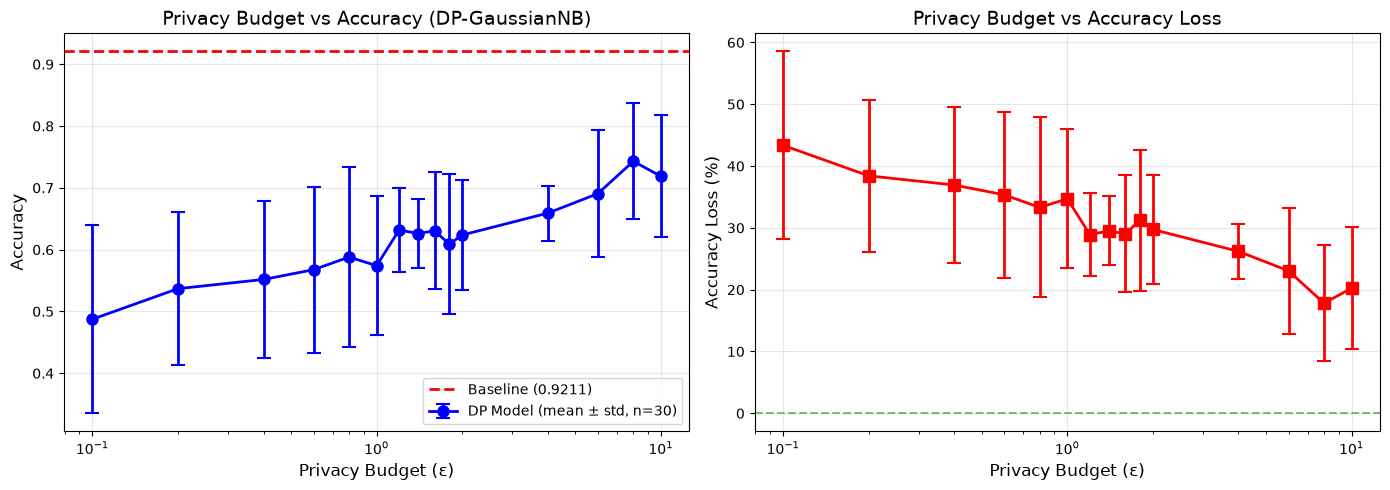


Plot saved as 'privacy_accuracy_tradeoff.png'


In [13]:
import os
os.makedirs('output', exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1: Epsilon vs Accuracy
ax1 = axes[0]
ax1.errorbar(
    results_df['epsilon'],
    results_df['accuracy_mean'],
    yerr=results_df['accuracy_std'],
    fmt='bo-', linewidth=2, markersize=8,
    capsize=5, capthick=1.5,
    label=f'DP Model (mean ± std, n={N_RUNS})'
)
if baseline_accuracy is not None:
    ax1.axhline(y=baseline_accuracy, color='r', linestyle='--',
                linewidth=2, label=f'Baseline ({baseline_accuracy:.4f})')
ax1.set_xlabel('Privacy Budget (ε)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Privacy Budget vs Accuracy (DP-GaussianNB)', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Plot 2: Epsilon vs Accuracy Loss
if baseline_accuracy is not None:
    ax2 = axes[1]
    ax2.errorbar(
        results_df['epsilon'],
        results_df['accuracy_loss_pct'],
        yerr=results_df['accuracy_std'] * 100,
        fmt='rs-', linewidth=2, markersize=8,
        capsize=5, capthick=1.5
    )
    ax2.set_xlabel('Privacy Budget (ε)', fontsize=12)
    ax2.set_ylabel('Accuracy Loss (%)', fontsize=12)
    ax2.set_title('Privacy Budget vs Accuracy Loss', fontsize=14)
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.axhline(y=0, color='g', linestyle='--', alpha=0.5)
 
plt.tight_layout()
plt.savefig('output/privacy_accuracy_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'output/privacy_accuracy_tradeoff.png'")

## 14. All Metrics vs Epsilon

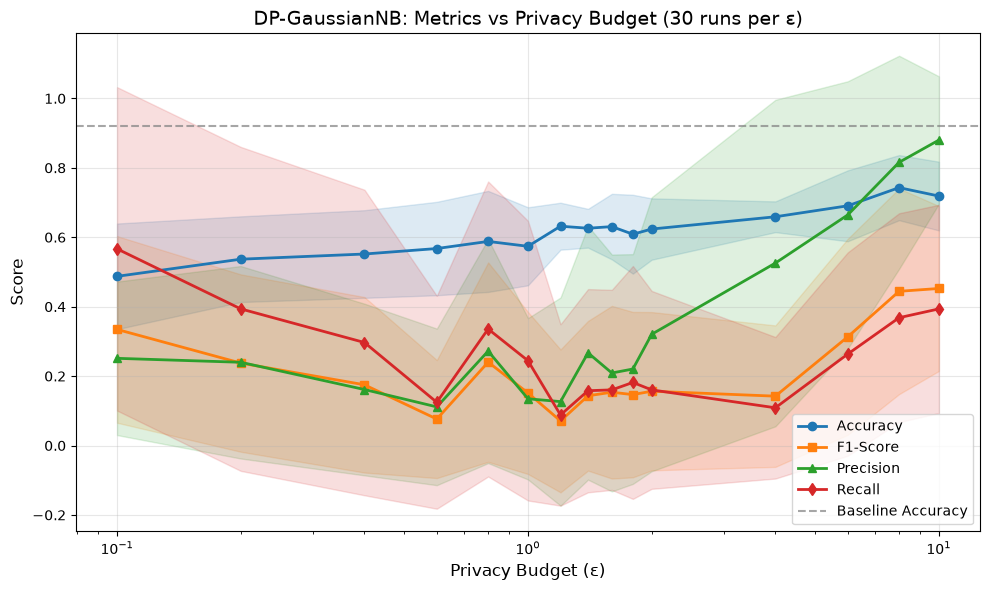

Plot saved as 'all_metrics_vs_epsilon.png'


In [14]:
import os
os.makedirs('output', exist_ok=True)
plt.figure(figsize=(10, 6))
 
metrics = [
    ('accuracy_mean', 'accuracy_std', 'Accuracy', 'o-'),
    ('f1_score_mean', 'f1_score_std', 'F1-Score', 's-'),
    ('precision_mean', 'precision_std', 'Precision', '^-'),
    ('recall_mean', 'recall_std', 'Recall', 'd-'),
]
 
for mean_col, std_col, label, fmt in metrics:
    mean_vals = results_df[mean_col].values
    std_vals = results_df[std_col].values
    eps_vals = results_df['epsilon'].values
 
    line = plt.plot(eps_vals, mean_vals, fmt, label=label, linewidth=2)
    color = line[0].get_color()
 
    plt.fill_between(
        eps_vals,
        mean_vals - std_vals,
        mean_vals + std_vals,
        alpha=0.15,
        color=color
    )
 
if baseline_accuracy is not None:
    plt.axhline(y=baseline_accuracy, color='gray', linestyle='--',
                alpha=0.7, label='Baseline Accuracy')
 
plt.xlabel('Privacy Budget (ε)', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title(f'DP-GaussianNB: Metrics vs Privacy Budget ({N_RUNS} runs per ε)', fontsize=14)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.savefig('output/all_metrics_vs_epsilon.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as 'output/all_metrics_vs_epsilon.png'")

## 15. Save Final Results

In [15]:
import os
os.makedirs('output', exist_ok=True)
results_df.to_csv('output/dp_results.csv', index=False)
print("DP results saved to 'output/dp_results.csv'")
 
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
if baseline_accuracy is not None:
    print(f"\nBaseline (Standard GaussianNB) Accuracy: {baseline_accuracy:.4f}")
print(f"\nDP Gaussian Naive Bayes Results ({N_RUNS} runs per epsilon):")
print(results_df.to_string(index=False))

print("\n" + "=" * 60)
print("IMPLEMENTATION DETAILS")
print("=" * 60)
print("Library: diffprivlib.models.GaussianNB")
print("Privacy Mechanism: Laplacian noise added to mean/variance estimation")
print("Bounds: Per-feature bounds for privacy calibration")

DP results saved to 'dp_results.csv'

FINAL SUMMARY

Baseline (Standard GaussianNB) Accuracy: 0.9211

DP Gaussian Naive Bayes Results (30 runs per epsilon):
 epsilon  accuracy_mean  accuracy_std  f1_score_mean  f1_score_std  precision_mean  precision_std  recall_mean  recall_std  balanced_accuracy_mean  balanced_accuracy_std  roc_auc_mean  roc_auc_std  train_time_mean  train_time_std  accuracy_loss_mean  accuracy_loss_pct
     0.1       0.487427      0.152182       0.334509      0.268839        0.251244       0.221106     0.566667    0.465856                0.503935               0.089955      0.516981     0.295400         0.011014        0.000889            0.433626          43.362573
     0.2       0.536842      0.123420       0.237598      0.255487        0.239848       0.277274     0.393651    0.466680                0.507011               0.049967      0.484325     0.304465         0.008332        0.000383            0.384211          38.421053
     0.4       0.551754      0.12627